In [1]:
from pathlib import Path
from typing import Union, Optional
import copy

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from spotpy.algorithms import _algorithm
import spotpy
import tqdm

In [ ]:
# Base class for a multidimensional database for the calibration. This could be used in future expansion to other formats
class MultiDimDb:
    format = None
    def __init__(
            self,
            dbname: str,
            dbpath: Union[str, Path],
            dims: Optional[dict] = None,
            dim_names: Optional[dict] = None,
            dbappend: bool = False,
            save_sim: bool = False,
    ):
        
        self.dbname = dbname
        self.cwd = dbpath
        self.dimensions = dims
        self.dim_names = dim_names
        self.dbappend = dbappend
        self.save_sim = save_sim


class MscuaSetup:
    # Define parameters here (before __init__) as variables

    def __init__(self, type='run_interation', dbase: Optional[Union[str, Path, MultiDimDb]] = None):
        self.setup_type = type

    def parameters(self):
        pass
    
    def simulation(self):
        pass

    def evaluation(self):
        pass

    def objectivefunction(self):
        pass


# accepts 2 types of setup classes, a MscuaSetup() object with attribute .setup_type = 'run_iteration' OR .setup_type = 'evaluate_iteration'
class MsCua:
    
    algorithm_name = "MSCUA"
    
    def __init__(
            self,
            setup_class: MscuaSetup,
            dbname: str = 'mscuaDb',
            dbformat: str = 'memory',
            dbappend: bool = False,
            iter_db: Union[str, Path, None] = None

    ):
        self.setup = setup_class
        if dbformat == 'memory':
            self.database = MemDb(dbname=dbname)
        else:
            raise NotImplementedError("Other databases not supported yet, choose 'memory'")
        self.observation_data = self.setup.evaluation()
        try:
            self.objective_function_names = self.setup.objfunc_names
        except AttributeError:
            self.objective_function_names = None

    def evaluate_iteration(self, dbase: MultiDimDb, objfunc_vals: dict, objfunc_thresh: dict):
        if dbase.format == 'memory':
            if not dbase.parameter_records:
                raise AttributeError("No paramter samples have been saved to the input database.")
            if len(dbase.simulation_results) == 0:
                raise AttributeError("No simulation data has been saved to the input database.")
            
            reps = len(dbase.simulation_results)
            for i in range(len(reps)):
                ob = self.setup.objectivefunction(self.observation_data, dbase.simulation_results[i])
                objfun_dict = {}
                if self.objective_function_names is None:
                    self.objective_function_names = []
                    for i in range(len(ob)):
                        self.objective_function_names.append(f"obfunc{i}")
                        objfun_dict[f"obfunc{i}"] = ob[i]
                else:
                    for i in range(len(ob)):
                        objfun_dict[self.objective_function_names[i]] = ob[i]
                dbase.save(objective_func=objfun_dict)
            
            for k in self.objective_function_names:
                

        else:
            raise NotImplementedError("Other databases not supported")

        pass

    def sample(self, objfunc_thresholds: dict):
        pass

    def _evaluate_rep(self):
        pass



# A child class of MultiDimDb that creates a set of zarr files to database calibration output
class ZarrDb(MultiDimDb):
    format = 'zarr'
    def __init__(self, *args, chunks: Optional[dict] = None, **kwargs):
        
        super(ZarrDb, self).__init__(*args, **kwargs)
        self.chunks = chunks
    
    def save(self):
        pass

    @staticmethod
    def load(dbpth: Union[str, Path]):
        pass

# create a netcdf with dummy data and then write to each region to fill it out...use chunks for dask capabilities?
class NetcdfDb(MultiDimDb):
    format = 'netcdf'
    def __init__(self, *args, chunks: Optional[dict] = None, **kwargs):
        
        super(NetcdfDb, self).__init__(*args, **kwargs)
        self.chunks = chunks
    
    def save(self):
        pass

    @staticmethod
    def load(dbpth: Union[str, Path]):
        pass


class MemDb(MultiDimDb):
    format = 'memory'

    def __init__(self, *args, **kwargs):
        
        super(MemDb, self).__init__(*args, dbpath=None, **kwargs)
        print("In Memory database initialized...")
        self._par = {}
        self._objfun = {}
        self._sim = []
    
    @property
    def simulation_results(self):
        return np.array(self._sim)
    
    @property
    def parameter_records(self):
        return self._par
    
    @property
    def objective_func_values(self):
        return self._objfun

    def save(self, param_dict: dict, objective_func: Optional[dict] = None, simulations: Optional[np.ndarray] = None):
        if (param_dict is None) & (objective_func is None) & (simulations is None):
            print("No data to save")
        else:
            if param_dict is not None:
                if not self._par:
                    self._par.update(param_dict)
                else:
                    for k,v in param_dict.items():
                        self._par[k] = np.vstack((self._par[k], v))
            
            if objective_func is not None:
                if not self._objfun:
                    self._objfun.update(objective_func)
                else:
                    for k,v in objective_func.items():
                        self._objfun[k] = np.vstack((self._objfun[k], v))
            
            if simulations is not None:
                self._sim.append(simulations)

    def to_xarray(self):
        pass


# This needs to accept only Uniform and List parameter types.
def LHS_md(params: list[spotpy.parameter.Base], repetitions: int, dbase: MultiDimDb):
    """

    Args:
        params:
        repetitions:
        dbase_name:
        dbase_format:

    """
    database = dbase
    param_dims = {}
    param_dim_names = {}
    for p in params:
        ndim = {p.name: p.dim}
        ndimname = {p.name: p.dim_name}
        param_dims.update(ndim)
        param_dim_names.update(ndimname)
    
    database.dims = param_dims
    database.dim_names = param_dim_names

    Is = np.linspace(0, 1, repetitions + 1)
    Ie = np.roll(Is, -1)
    Is = Is[:-1].copy()
    Ie = Ie[:-1].copy()
    paramdict = {}
    for p in params:
        if p.rndfunctype == 'List':
            val_arr = p.values
            if val_arr.shape != 2:
                raise ValueError("For multidimensional LHS, a 2D paramter array is required for 'List' type.")
        else:
            vals = np.linspace(p.minbound, p.maxbound, repetitions)
            val_arr = np.repeat(vals[:,None], p.dim, axis=1)
        print(f"Sampling {repetitions} repetitions of the {p.name} parameter...")
        samples = []
        for i in tqdm.tqdm(range(len(Is)), desc=f'{p.name} samples', leave=False):
            rs_p = np.random.uniform(Is[i], Ie[i], 1)
            rs_v = np.nanquantile(val_arr, rs_p[0], axis=0)
            samples.append(rs_v)

        paramdict.update({p.name: np.array(samples)})
        
    # "Shuffle" or randomize the parameter sets (or combinations)
    for k,v in paramdict.items():
        np.random.shuffle(v)
        paramdict[k] = v
    
    database.save(paramdict)
    
    if database.format == 'memory':
        if database.parameter_records != paramdict:
            paramdict = copy.deepcopy(database.parameter_records)
        return paramdict, database
    else:    
        return paramdict


# function to build parameter list to be input into LHS function, include dimensions and dimension names as attributes of spotpy.parameter objects
def build_parameter_list(setup: MscuaSetup, parameter_dim: dict, parameter_dim_name: dict):
    
    cls = type(setup)
    class_vars = vars(cls).items()
    parameters = []
    for attrname, attrobj in class_vars:
        # Check if it is a spotpy parameter
        if isinstance(attrobj, spotpy.parameter.Base):
            if not attrobj.name:
                attrobj.name = attrname
            
            attrobj.dim = parameter_dim[attrobj.name]
            attrobj.dim_name = parameter_dim_name[attrobj.name]
            
            if attrobj.rndfunctype == 'List':
                if isinstance(attrobj.values, list):
                    attrobj.values = np.array(attrobj.values)
                if len(attrobj.values.shape) == 1:
                    if attrobj.values.shape[0] != parameter_dim[attrobj.name]:
                        raise ValueError("The provided parameter dimensions do not match the length of the List Parameter values.")
                    attrobj.maxbound = attrobj.values.max()
                    attrobj.minbound = attrobj.values.min()
                elif len(attrobj.values.shape) == 2:
                    if attrobj.values.shape[1] != parameter_dim[attrobj.name]:
                        raise ValueError("The provided parameter dimensions do not match the length of the List Parameter values.")
                    attrobj.maxbound = attrobj.values.max(axis=0)
                    attrobj.minbound = attrobj.values.min(axis=0)
                else:
                    raise NotImplementedError("List Parameter type with > 2 dimensions is not supported.")

            # Add parameter
            parameters.append(attrobj)

    return parameters


def query_parameters(params: Union[dict, MultiDimDb], rep_id: int):
    
    if rep_id == 0:
        raise IndexError("The rep_id argument is not zero based, for the first sample use rep_id=1")
    idx = rep_id - 1
    
    if isinstance(params, dict):
        q_par = {}
        for k,v in params.items():
            try:
                q = {k: v[idx,:]}
            except IndexError:
                print(f"rep_id = {rep_id}, there are only {v.shape[0]} parameters samples to query")
            q_par.update(q)
    elif isinstance(params, MultiDimDb):
        if params.format == 'memory':
            q_par = {}
            for k,v in params.parameter_records.items():
                try:
                    q = {k: v[idx,:]}
                except IndexError:
                    print(f"rep_id = {rep_id}, there are only {v.shape[0]} parameters samples to query")
                q_par.update(q)
        else:
            # need to query xarray dataset here and return a dict
            q_par = {}
    
    return q_par
    


In [ ]:
#maybe make obj func threshold functions?
def greater_than(obfunc: np.ndarray, thresh: Union[int, float]):
    return np.where(obfunc > thresh)

def less_than(obfunc: np.ndarray, thresh:)

## Define Multidimensional Objective Functions

In [ ]:
def mse_md(observation: np.ndarray, simulation: np.ndarray):
    if observation.size == simulation.size:
        mse = np.nanmean((observation - simulation) ** 2, axis=0)
        return mse
    else:
        raise ValueError("evaluation and simulation data do not have the same length.")


def rmse_md(observation: np.ndarray, simulation: np.ndarray):
    if observation.size == simulation.size:
        rmse = np.sqrt(mse_md(observation, simulation))
        return rmse
    else:
        raise ValueError("evaluation and simulation data do not have the same length.")


def nrmse_md(observation: np.ndarray, simulation: np.ndarray):
    if observation.size == simulation.size:
        nrmse = rmse_md(observation, simulation) / np.nanmean(observation, axis=0)
        return nrmse
    else:
        raise ValueError("evaluation and simulation data do not have the same length.")


def nse_md(observation: np.ndarray, simulation: np.ndarray):
    if observation.size == simulation.size:
        mean_observed = np.nanmean(observation, axis=0)
        # compute numerator and denominator
        numerator = np.nansum((observation - simulation) ** 2, axis=0)
        denominator = np.nansum((observation - mean_observed) ** 2, axis=0)
        # compute coefficient
        return 1 - (numerator / denominator)
    else:
        raise ValueError("evaluation and simulation data do not have the same length.")


def pbias_md(observation: np.ndarray, simulation: np.ndarray):
    if observation.size == simulation.size:
        pbias = np.nansum(simulation - observation, axis=0) / np.nansum(observation, axis=0)
        return pbias
    else:
        raise ValueError("evaluation and simulation data do not have the same length.")


## Build a Dummy Model with Input Data & Observation Dataset

This is a simple Power-Law Function...it will serve as our model.

In [3]:
def exp_model(x, coef, exp):
    y = coef * x**(exp)
    return y

Create a set of random input values.

In [4]:
indata = np.random.uniform(1.0, 30.0, size=1000)

Run the model and add noise to the results to create our observation dataset.

In this case our target parameters are:
- coef = 0.03
- exp = 3.3

But for the actual calibration we will run the algorithm on 2000 power functions at once.

In [5]:
outdata = exp_model(indata, 0.03, 3.3)
inrng = outdata.max() - outdata.min()
noise = np.random.uniform(-inrng * 0.04, inrng * 0.04, size=outdata.shape)
obsdata = outdata + noise

Plot the observation data to inspect.

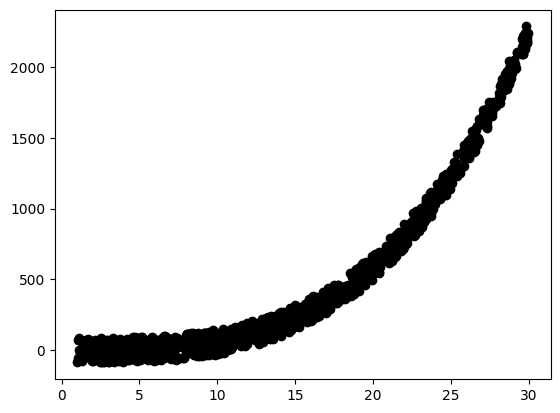

In [6]:
ax = plt.axes()
ax.plot(indata, obsdata, 'ko')

Ok, create the full multidimensional model and observation data.

In [53]:
target_coef = np.random.uniform(low=0.0001, high=3.0, size=2000)
target_exp = np.random.uniform(low=1.0, high=4.0, size=2000)
mdindata = indata.reshape((indata.shape[0], 1))
outdata = exp_model(mdindata, target_coef, target_exp)
inrng = outdata.max(axis=0) - outdata.min(axis=0)
noise = np.random.uniform(-0.04, 0.04, size=(outdata.shape[0], 1))
mdnoise = noise * inrng
obsdata = outdata + mdnoise

Plot it to confirm that there are indeed 2000 "distinct" models in the array.

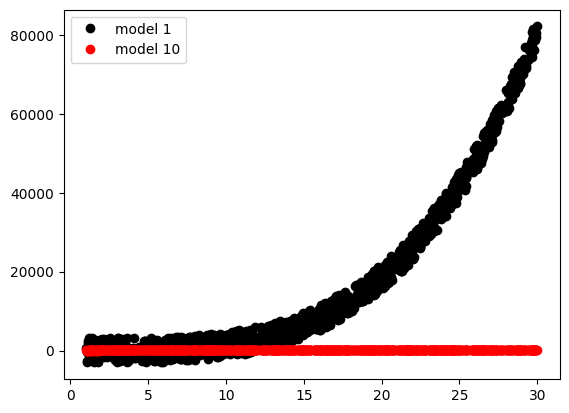

In [54]:
ax = plt.axes()
ax.plot(indata, obsdata[:,0], 'ko', label='model 1')
ax.plot(indata, obsdata[:,9], 'ro', label='model 10')
ax.legend()

Now we define the Setup Class for the calibration algorithm.

In [ ]:
class MscuaSetup:
    # Define parameters here (before __init__) as variables
    coef = spotpy.parameter.Uniform(low=0.0001, high=3.0)
    exp = spotpy.parameter.Uniform(low=1.0, high=4.0)

    def __init__(self, type='run_interation', dbase: Optional[Union[str, Path, MultiDimDb]] = None):
        self.setup_type = type
        # define the multidimensional parameter space here
        self.parameter_dimension = {
            'coef': 2000,
            'exp': 2000,
        }
        self.param_dim_names = {
            'coef': 'curve',
            'exp': 'curve',
        }
        self.indata = mdindata
        self.observation_data = obsdata
        self.objfunc_names = ['rmse']
    
    def simulation(self, paramdict):
        modout = exp_model(self.indata, **paramdict)

        return modout
        

    def evaluation(self):
        return self.observation_data

    def objectivefunction(self, observation, simulation):
        pass

In [56]:
setup = MscuaSetup()

In [19]:
plist = build_parameter_list(setup, setup.parameter_dimension, setup.param_dim_names)

In [20]:
testdb = MemDb(dbname='test')

In Memory database initialized...


In [21]:
samples = LHS_md(plist, repetitions=1000, dbase=testdb)

coef samples:   0%|          | 5/1000 [00:00<00:21, 46.66it/s]

Sampling 1000 repetitions of the coef parameter...


exp samples:   1%|          | 6/1000 [00:00<00:18, 53.24it/s]   

Sampling 1000 repetitions of the exp parameter...


In [85]:
qp = query_parameters(samples[0], 500)

In [86]:
qp

{'coef': array([1.07338486, 1.07338486, 1.07338486, ..., 1.07338486, 1.07338486,
        1.07338486]),
 'exp': array([1.11767566, 1.11767566, 1.11767566, ..., 1.11767566, 1.11767566,
        1.11767566])}

In [88]:
testrun = setup.simulation(qp)

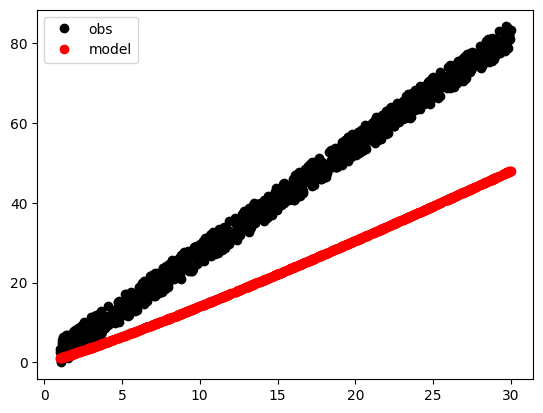

In [95]:
ax = plt.axes()
ax.plot(indata, obsdata[:,6], 'ko', label='obs')
ax.plot(indata, testrun[:,6], 'ro', label='model')
ax.legend()

In [112]:
nrmse_md(obsdata, testrun)

array([1.57671132, 1.08041582, 1.43176378, ..., 0.60310003, 1.08590264,
       1.45959881])

In [114]:
pbias_md(obsdata, testrun)

array([-0.99869265, -0.84241013, -0.97789159, ..., -0.5345455 ,
       -0.87984161, -0.99666129])

In [118]:
nse_md(obsdata, testrun)

array([-0.66812361, -0.9817588 , -0.83167237, ..., -0.20086509,
       -1.36382169, -0.86716904])

In [365]:
for k,v in p.items():
    np.random.shuffle(v)
    p[k] = v

In [366]:
paramdict

{'coef': array([[0.32034312, 0.32034312, 0.32034312, ..., 0.32034312, 0.32034312,
         0.32034312],
        [0.79870386, 0.79870386, 0.79870386, ..., 0.79870386, 0.79870386,
         0.79870386],
        [0.87528652, 0.87528652, 0.87528652, ..., 0.87528652, 0.87528652,
         0.87528652],
        ...,
        [0.22312686, 0.22312686, 0.22312686, ..., 0.22312686, 0.22312686,
         0.22312686],
        [2.89627277, 2.89627277, 2.89627277, ..., 2.89627277, 2.89627277,
         2.89627277],
        [1.46816149, 1.46816149, 1.46816149, ..., 1.46816149, 1.46816149,
         1.46816149]]),
 'exp': array([[3.98961219, 3.98961219, 3.98961219, ..., 3.98961219, 3.98961219,
         3.98961219],
        [3.23585835, 3.23585835, 3.23585835, ..., 3.23585835, 3.23585835,
         3.23585835],
        [2.97202066, 2.97202066, 2.97202066, ..., 2.97202066, 2.97202066,
         2.97202066],
        ...,
        [2.56133221, 2.56133221, 2.56133221, ..., 2.56133221, 2.56133221,
         2.56133221

In [119]:
a = np.array([[1,2,3,4],[2,3,4,5]])
b = np.array([[4,5,6,7],[5,6,7,8]])

In [123]:
c = np.array([a])

In [127]:
c[1]

IndexError: index 1 is out of bounds for axis 0 with size 1

In [120]:
np.concatenate([a,b])

array([[1, 2, 3, 4],
       [2, 3, 4, 5],
       [4, 5, 6, 7],
       [5, 6, 7, 8]])

In [256]:
a = np.array([[1,2,3],[2,3,4],[5,6,7],[6,5,4]])

In [261]:
d = {'a': a}

In [274]:
list(d.keys())

['a']

In [34]:
np.vstack((a, np.array([3,4,5])))

array([[1, 2, 3],
       [2, 3, 4],
       [3, 4, 5]])

In [33]:
np.append(a, np.array([[3,4,5]]), axis=0)

array([[1, 2, 3],
       [2, 3, 4],
       [3, 4, 5]])

In [28]:
l = [a, a, a, a]

In [29]:
np.array(l).shape

(4, 2, 3)

In [40]:
np.random.shuffle(idx[:,0])

In [30]:
np.random.uniform(0.1, 0.95, (12, 45000, 1000))

array([[[0.42355468, 0.86204125, 0.54015131, ..., 0.5700918 ,
         0.69759853, 0.26874137],
        [0.24035768, 0.54461723, 0.60441547, ..., 0.14618263,
         0.25839244, 0.82395398],
        [0.21930125, 0.4802879 , 0.13330379, ..., 0.58991011,
         0.57764442, 0.5162041 ],
        ...,
        [0.35716117, 0.85010104, 0.85845567, ..., 0.39194869,
         0.12792978, 0.67392425],
        [0.17834936, 0.43163659, 0.24773113, ..., 0.17936848,
         0.75911941, 0.27489299],
        [0.92953885, 0.35206192, 0.59843987, ..., 0.38847575,
         0.49485421, 0.6571009 ]],

       [[0.85383807, 0.16367031, 0.27617537, ..., 0.51565362,
         0.1750666 , 0.81193191],
        [0.12087655, 0.4087516 , 0.22960585, ..., 0.51578871,
         0.58466209, 0.20398288],
        [0.53682553, 0.50725984, 0.61841429, ..., 0.72015347,
         0.57633741, 0.38855757],
        ...,
        [0.85032219, 0.80499915, 0.54562597, ..., 0.53897735,
         0.85933891, 0.26085836],
        [0.7

In [3]:
a = spotpy.parameter.List([0.4,0.1,0.5,0.2], name='alpha', repeat=True)

In [44]:
b = spotpy.parameter.Uniform(low=0.0, high=1.0, name='beta')

In [47]:
b.shape = 45

In [49]:
b(size=b.shape)

array([0.14836256, 0.29714631, 0.43969959, 0.44673499, 0.80642436,
       0.76363072, 0.1056641 , 0.63102631, 0.02609012, 0.75163369,
       0.29332294, 0.8673099 , 0.65829019, 0.94698996, 0.07360103,
       0.63054943, 0.71858701, 0.0978795 , 0.99946676, 0.24960378,
       0.80919863, 0.58248523, 0.93754703, 0.42158445, 0.76649583,
       0.23499048, 0.40845448, 0.43330156, 0.36017104, 0.82033355,
       0.50296113, 0.24423523, 0.43803434, 0.60922195, 0.34184762,
       0.89691675, 0.4427719 , 0.00347332, 0.85407069, 0.38343502,
       0.57766285, 0.4008637 , 0.10342616, 0.42016671, 0.73820038])

In [67]:
a.minbound = np.nanmin(a.values)

In [9]:
a(6)

array([0.4, 0.1, 0.5, 0.2, 0.4, 0.1])

In [7]:
class SpotpySetup:
    dday_intcp = spotpy.parameter.Uniform(low=-60.0, high=10.0)
    dday_slope = spotpy.parameter.Uniform(low=0.1, high=1.4)
    ppt_rad_adj = spotpy.parameter.Uniform(low=0.0, high=0.5)
    radadj_intcp = spotpy.parameter.Uniform(low=0.0, high=1.0)
    radadj_slop = spotpy.parameter.Uniform(low=0.0, high=1.0)
    radj_sppt = spotpy.parameter.Uniform(low=0.0, high=1.0)
    radj_wppt = spotpy.parameter.Uniform(low=0.0, high=1.0)
    radmax = spotpy.parameter.Uniform(low=0.1, high=1.0)
    tmax_index = spotpy.parameter.Uniform(low=-10.0, high=110.0)

In [8]:
setup = SpotpySetup()

In [21]:
params = [
    spotpy.parameter.Uniform(name='dday_intcp', low=-60.0, high=10.0)
]

In [25]:
params[0].name

'dday_intcp'

In [23]:
spotpy.parameter.generate(params)

array([(1.8660512, 'dday_intcp', 6.946, -24.85, -60., 9.999, False)],
      dtype=[('random', '<f8'), ('name', '<U100'), ('step', '<f8'), ('optguess', '<f8'), ('minbound', '<f8'), ('maxbound', '<f8'), ('as_int', '?')])

In [3]:
class SpotpySetup:
    a = spotpy.parameter.Uniform(0.1, 0.9)
    b = spotpy.parameter.List([0.4,0.1,0.5,0.2], repeat=True)
    b.minbound = np.min(b.values)
    b.maxbound = np.max(b.values)

In [4]:
setup = SpotpySetup()

In [5]:
p = spotpy.parameter.get_parameters_from_setup(setup)

In [6]:
p

[Uniform('a', [0.1, 0.9]), List('b', [[0.4, 0.1, 0.5, 0.2]])]

In [82]:
cls = type(setup)
class_variables = vars(cls).items()

In [95]:
class_vars = dict(vars(cls)).items()
params = {}
for k,v in class_vars:
    if isinstance(v, spotpy.parameter.Base):
        params[k] = v
    

In [ ]:
params['b']

0.1

In [92]:
class_vars

{'__module__': '__main__',
 'a': Uniform('a', [0.1, 0.9]),
 'b': List('b', [[0.4, 0.1, 0.5, 0.2]]),
 '__dict__': <attribute '__dict__' of 'SpotpySetup' objects>,
 '__weakref__': <attribute '__weakref__' of 'SpotpySetup' objects>,
 '__doc__': None}

In [ ]:
params = []
for attrname, attrobj in class_variables:
    if isinstance(attrobj, spotpy.parameter.Base):
        params.append(attrobj)

dict_items([('__module__', '__main__'), ('a', Uniform('a', [0.1, 0.9])), ('b', List('b', [[0.4, 0.1, 0.5, 0.2]])), ('__dict__', <attribute '__dict__' of 'SpotpySetup' objects>), ('__weakref__', <attribute '__weakref__' of 'SpotpySetup' objects>), ('__doc__', None)])

In [74]:
spotpy.parameter.generate(p)

array([(0.82150173, 'a', 0.08042, 0.5008, 0.1, 0.9, False),
       (       nan, 'b', 0.     , 0.    , 0. , 0. , False)],
      dtype=[('random', '<f8'), ('name', '<U100'), ('step', '<f8'), ('optguess', '<f8'), ('minbound', '<f8'), ('maxbound', '<f8'), ('as_int', '?')])

In [39]:
spotpy.parameter.get_parameters_array(setup)

array([(0.14661096, 'a', 0.08121, 0.5007, 0.1, 0.9, False),
       (       nan, 'b', 0.     , 0.    , 0. , 0. , False)],
      dtype=[('random', '<f8'), ('name', '<U100'), ('step', '<f8'), ('optguess', '<f8'), ('minbound', '<f8'), ('maxbound', '<f8'), ('as_int', '?')])

In [19]:
np.random.choice(a.values, (2,2))

array([[0.5, 0.1],
       [0.5, 0.2]])

In [54]:
dts = pd.date_range('2020-01-01', '2024-12-31', freq='D')

In [55]:
d = np.random.random((len(dts),40000))

In [56]:
d = d[:,:,None]

In [57]:
test = xr.Dataset(
    {'srad': (['time', 'hru', 'repitition'], d)},
    coords={
        'time': dts,
        'hru': np.arange(d.shape[1]),
        'repitition': np.array([2])
    }
)

In [58]:
test = test.chunk({'time':1000, 'hru':1000})

In [59]:
test

<xarray.Dataset>
Dimensions:     (time: 1827, hru: 40000, repitition: 1)
Coordinates:
  * time        (time) datetime64[ns] 2020-01-01 2020-01-02 ... 2024-12-31
  * hru         (hru) int32 0 1 2 3 4 5 ... 39994 39995 39996 39997 39998 39999
  * repitition  (repitition) int32 2
Data variables:
    srad        (time, hru, repitition) float64 dask.array<chunksize=(1000, 1000, 1), meta=np.ndarray>

In [60]:
test.to_zarr(r'C:\Users\CNB968\Documents\test.zarr', mode='a', append_dim='repitition')

In [64]:
z = xr.open_zarr(Path(r'C:\Users\CNB968\Documents\test.zarr'))

In [65]:
z

<xarray.Dataset>
Dimensions:     (hru: 40000, repitition: 2, time: 1827)
Coordinates:
  * hru         (hru) int32 0 1 2 3 4 5 ... 39994 39995 39996 39997 39998 39999
  * repitition  (repitition) int32 1 2
  * time        (time) datetime64[ns] 2020-01-01 2020-01-02 ... 2024-12-31
Data variables:
    srad        (time, hru, repitition) float64 dask.array<chunksize=(1000, 1000, 1), meta=np.ndarray>

In [28]:
s = z.sel(repitition=1).srad.values
o = z.sel(repitition=2).srad.values

In [29]:
spotpy.objectivefunctions.nashsutcliffe(o, s)

-0.9997623094287522

In [27]:
v = np.array([0.1,0.2,0.2,1.1])
a = np.array([0,0,0,0,1,1,1,0,0,0,3,3,0,2,2,2,2,2,0,0,0,0])
subid = np.array([0,1,2,3])

In [ ]:
na = np.ones
for i in range(subid.size):
    idx = subid[i]
    val = v[i]
    a[a==idx] = val


In [25]:
a[a==subid[0]] = v[0]

In [38]:
amd = np.tile(a, (5,1))

In [39]:
amd = amd.astype(float)

In [42]:
amd[np.array([[0],[1],[2],[3],[4]]), np.array([[0, 4], [0,4], [0,4], [0,4], [0,4]])] = np.array([[0.1],[0.2],[0.3],[0.2],[0.1]])

In [ ]:
np.array([])

array([[0.1, 0. , 0. , 0. , 0.1, 1. , 1. , 0. , 0. , 0. , 3. , 3. , 0. ,
        2. , 2. , 2. , 2. , 2. , 0. , 0. , 0. , 0. ],
       [0.2, 0. , 0. , 0. , 0.2, 1. , 1. , 0. , 0. , 0. , 3. , 3. , 0. ,
        2. , 2. , 2. , 2. , 2. , 0. , 0. , 0. , 0. ],
       [0.3, 0. , 0. , 0. , 0.3, 1. , 1. , 0. , 0. , 0. , 3. , 3. , 0. ,
        2. , 2. , 2. , 2. , 2. , 0. , 0. , 0. , 0. ],
       [0.2, 0. , 0. , 0. , 0.2, 1. , 1. , 0. , 0. , 0. , 3. , 3. , 0. ,
        2. , 2. , 2. , 2. , 2. , 0. , 0. , 0. , 0. ],
       [0.1, 0. , 0. , 0. , 0.1, 1. , 1. , 0. , 0. , 0. , 3. , 3. , 0. ,
        2. , 2. , 2. , 2. , 2. , 0. , 0. , 0. , 0. ]])

In [45]:
x = xr.Dataset()
x['test'] = (('x','y'), np.ones((25,25)))

In [100]:
et=xr.open_dataset(r'F:\BOR_UYWS_2025\OpenET_monthly_ensemble_mm_2020_2024\UY_ET_ensemble_monthly_mm_2020_2024.nc')

In [114]:
import rioxarray
import geopandas as gpd
import GRIDtools as gt
import xvec

In [ ]:
et = et.rio.set_crs(4326)

In [112]:
grid_pth = Path('D:/ArcGIS_Projects/Yellowstone/Upper Yellowstone/prms/UY_prms_grid.shp')
geom_grid = gpd.read_file(grid_pth)
wgs_grid = geom_grid.to_crs(4326)

In [113]:
gzon = gt.calc_zonal_stats(wgs_grid, et, all_touched=True)

C:\Users\CNB968\AppData\Local\Temp\ipykernel_11024\1586805462.py:1: UserWarning: Not all geometries were returned, 14 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  gzon = gt.calc_zonal_stats(wgs_grid, et, all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


c:\Users\CNB968\.conda\envs\prms\lib\site-packages\GRIDtools\zonal.py:241: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cntrs = missed_polys.centroid


In [119]:
gzon_xr = gzon.to_xarray()

In [123]:
gzon_xr

<xarray.Dataset>
Dimensions:  (FID: 45244, time: 60, stat: 2)
Coordinates:
  * FID      (FID) int64 0 1 2 3 4 5 6 ... 45238 45239 45240 45241 45242 45243
  * time     (time) datetime64[ns] 2020-01-01 2020-02-01 ... 2024-12-01
  * stat     (stat) object 'mean' 'single_point'
Data variables:
    ET       (FID, time, stat) float64 7.877 nan 8.085 nan ... nan 7.717 nan

In [128]:
zonmn = gzon_xr.sel(stat='mean').ET
zonsi = gzon_xr.sel(stat='single_point').ET

In [130]:
mnna = xr.where(zonmn.isnull(), zonsi, zonmn)

In [145]:
mnna = zonmn.fillna(zonsi)

In [154]:
mnna.values[mnna.isnull().values].size

2810

In [163]:
tdim = len(gzon.index.get_level_values(1).unique())
ldim = len(gzon.index.get_level_values(0).unique())

In [168]:
gzon.index.get_level_values(0).unique()

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       45234, 45235, 45236, 45237, 45238, 45239, 45240, 45241, 45242, 45243],
      dtype='int64', name='FID', length=45244)

In [170]:
gzon.loc[(0, slice(None), slice(None)),:].values

array([[  7.87677725],
       [  8.08530806],
       [ 41.95734597],
       [ 60.18957346],
       [ 78.7535545 ],
       [ 79.78199052],
       [104.22274882],
       [ 69.64454976],
       [ 32.34597156],
       [ 13.46445498],
       [  4.81990521],
       [  6.82938389],
       [  9.55924171],
       [ 15.22748815],
       [ 31.8436019 ],
       [ 47.69668246],
       [ 69.4028436 ],
       [ 93.58767773],
       [ 72.6492891 ],
       [ 52.17061611],
       [ 37.27014218],
       [ 23.60663507],
       [ 18.57819905],
       [  2.75829384],
       [  7.96208531],
       [ 11.58293839],
       [ 36.16587678],
       [ 51.27488152],
       [ 71.81042654],
       [ 79.12322275],
       [ 89.90521327],
       [ 45.18483412],
       [ 25.76303318],
       [ 16.18009479],
       [  5.22748815],
       [  9.58293839],
       [ 13.21327014],
       [ 20.6492891 ],
       [  7.65402844],
       [ 57.90521327],
       [ 63.2464455 ],
       [ 94.11848341],
       [118.1042654 ],
       [ 73

In [177]:
dsvals = gzon.values.reshape((ldim, tdim)).T

In [183]:
gzon.index.get_level_values(0).unique().values + 1

array([    1,     2,     3, ..., 45242, 45243, 45244], dtype=int64)

In [184]:
etds = xr.Dataset(
    {'actual_et': (['time', 'hru'], dsvals, et.ET.attrs)},
    coords={
        'time': gzon.index.get_level_values(1).unique().values,
        'hru': gzon.index.get_level_values(0).unique().values + 1
    }
)

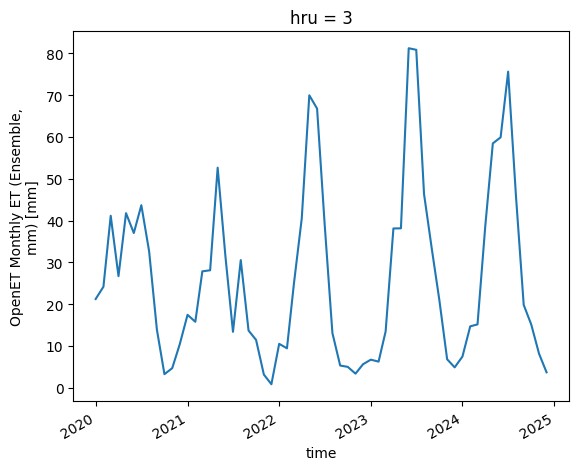

In [194]:
etds.sel(hru=3).actual_et.plot()

In [ ]:
geom_grid.geometry.get_coordinates().loc[0,:].values

array([    0,     1,     2, ..., 45241, 45242, 45243], dtype=int64)

In [202]:
etds.sel(time='2022-06-01').actual_et.values

array([ 79.12322275,  62.48837209,  66.78125   , ...,  81.97395757,
       133.26919554,  90.38282843])

In [242]:
mnet = etds.actual_et.mean(dim='time')

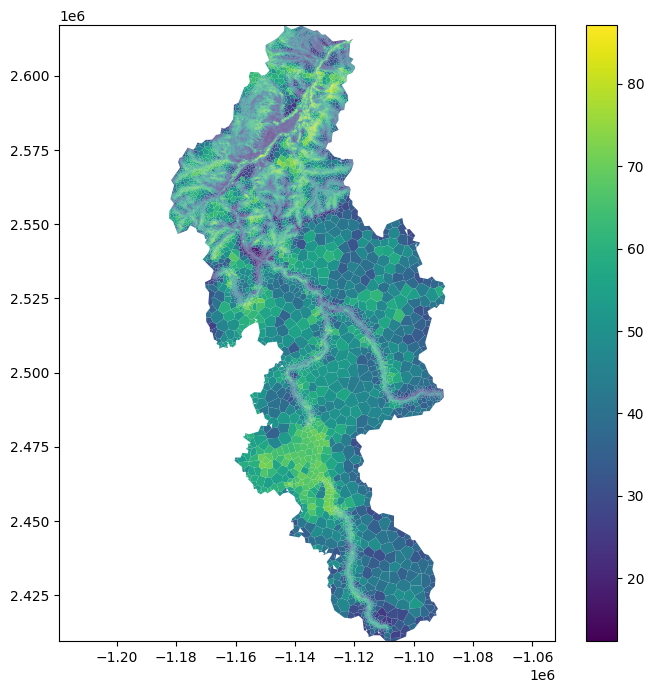

In [244]:
import matplotlib.pyplot as plt
from matplotlib.path import Path as mpPath
from matplotlib.collections import PathCollection

grd_vertices = geom_grid.geometry.get_coordinates()
gbnds = geom_grid.total_bounds
mp_pths = []
for i in geom_grid.index:
    np = mpPath(grd_vertices.loc[i,:].values)
    mp_pths.append(np)

kwargs = {}
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
collection = PathCollection(mp_pths)
collection.set_array(mnet.values)
vmin = kwargs.pop("vmin", None)
vmax = kwargs.pop("vmax", None)
kwargs["cmap"] = "viridis"
collection.set_clim(vmin=vmin, vmax=vmax)
collection.set(**kwargs)
ax.add_collection(collection)
ax.set_xlim(gbnds[0], gbnds[2])
ax.set_ylim(gbnds[1], gbnds[3])
fig.colorbar(collection, ax=ax)


In [246]:
etds.to_netcdf('D:/Modeling/GSFLOW/PRMS_Projects/Upper Yellowstone/calibration_data/OpenET_by_HRU_2020_2024.nc')